In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
import getdist
from getdist import loadMCSamples, plots
import warnings

In [2]:
filepaths = [
    '/project/chihway/junzhou/cocoa/Cocoa/projects/roman_real/chains/dc1_chains/dc1_solution_maindatavector_MCMC',
    '/project/chihway/junzhou/cocoa/Cocoa/projects/roman_real/chains/old_dc1_chains/dc1_solution_maindatavector_MCMC'
]

def load(filepath, settings):
    samples = loadMCSamples(filepath, settings=settings)
    p = samples.getParams()
    s8 = p.sigma8*(p.omegam/0.3)**0.5
    try:
        samples.addDerived(
            s8,
            'S8',
            label = r'S_8',
        )
    except:
        True
    return samples
settings = {'ignore_rows':0.3, 'contours': [0.68, 0.95]}
samples_new = load(filepaths[0], settings = settings)
samples_old = load(filepaths[1], settings = settings)

/project/chihway/junzhou/cocoa/Cocoa/projects/roman_real/chains/dc1_chains/dc1_solution_maindatavector_MCMC.1.txt
/project/chihway/junzhou/cocoa/Cocoa/projects/roman_real/chains/dc1_chains/dc1_solution_maindatavector_MCMC.2.txt
/project/chihway/junzhou/cocoa/Cocoa/projects/roman_real/chains/dc1_chains/dc1_solution_maindatavector_MCMC.3.txt
/project/chihway/junzhou/cocoa/Cocoa/projects/roman_real/chains/dc1_chains/dc1_solution_maindatavector_MCMC.4.txt
/project/chihway/junzhou/cocoa/Cocoa/projects/roman_real/chains/dc1_chains/dc1_solution_maindatavector_MCMC.5.txt
/project/chihway/junzhou/cocoa/Cocoa/projects/roman_real/chains/dc1_chains/dc1_solution_maindatavector_MCMC.6.txt
/project/chihway/junzhou/cocoa/Cocoa/projects/roman_real/chains/dc1_chains/dc1_solution_maindatavector_MCMC.7.txt
/project/chihway/junzhou/cocoa/Cocoa/projects/roman_real/chains/dc1_chains/dc1_solution_maindatavector_MCMC.8.txt
Removed 0.3 as burn in


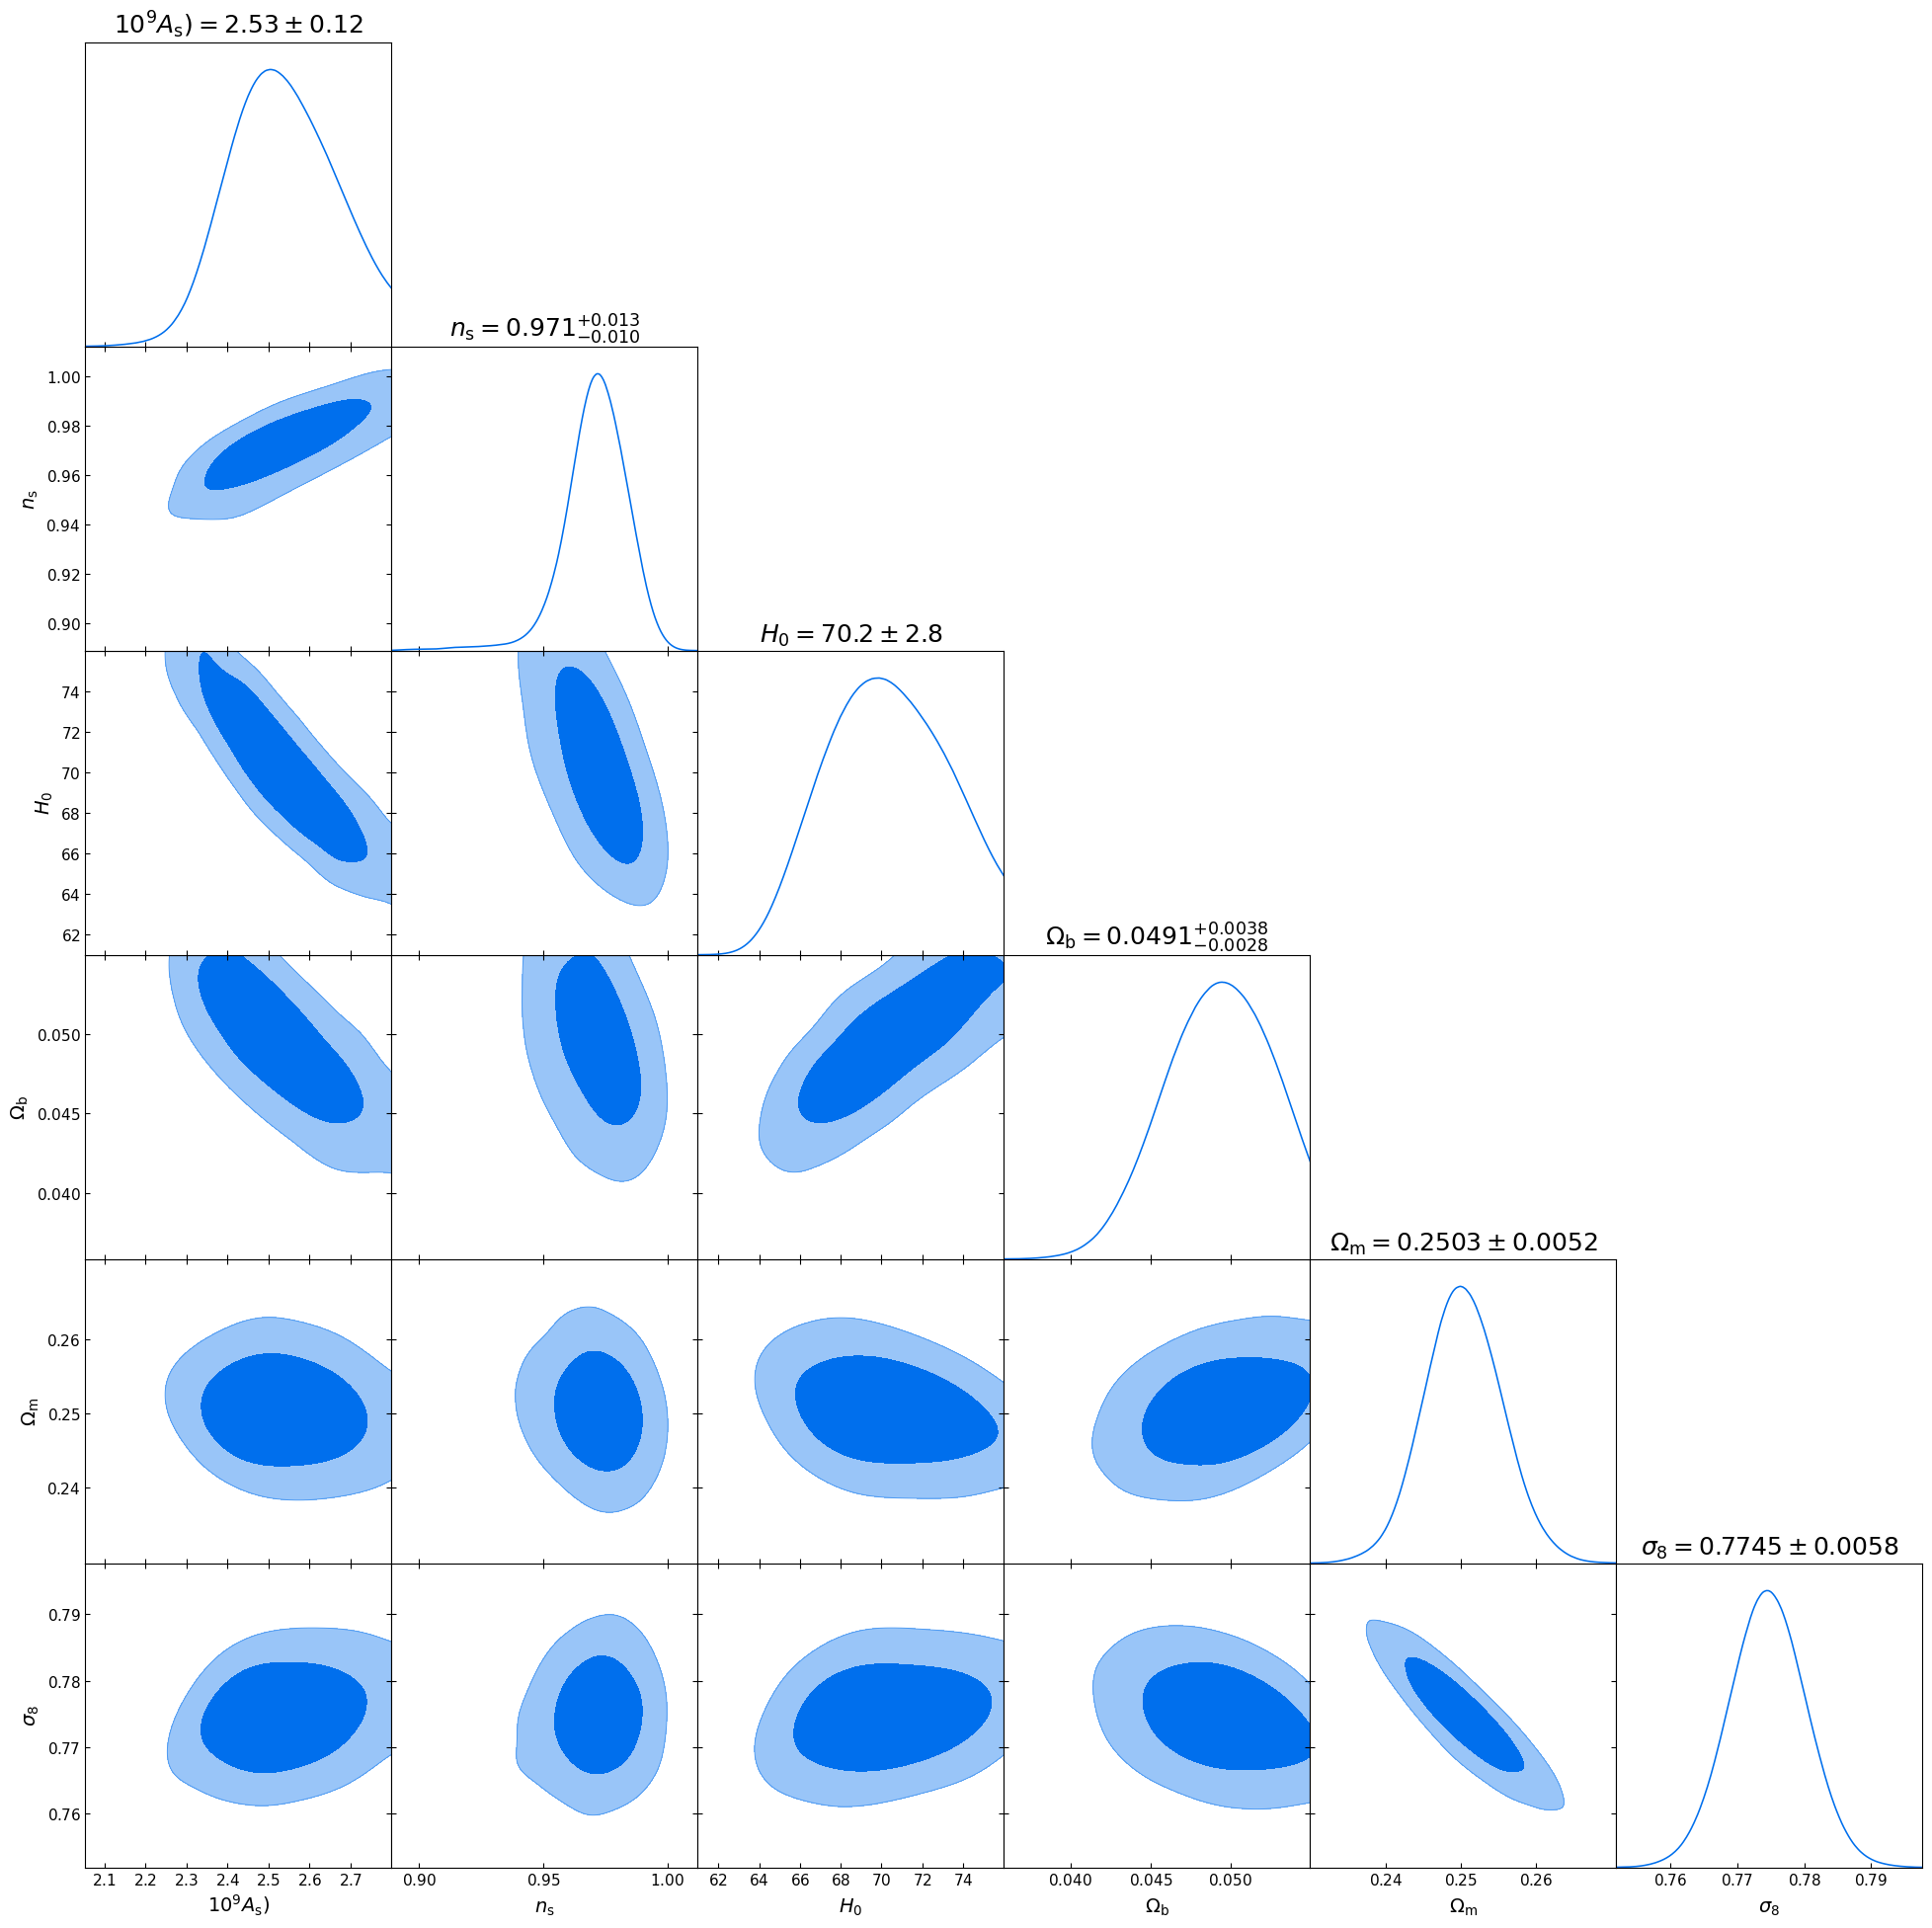

In [4]:
g = plots.get_subplot_plotter(subplot_size=4)
g.settings.title_limit = 1            
g.settings.title_limit_labels = True  
g.settings.title_limit_fontsize = 18

params = ['As_1e9','ns','H0','omegab','omegam','sigma8']

g.triangle_plot(samples_new, params=params, filled=True,
                marker_args={'ls':'--','lw':1.2,'color':'k','alpha':0.8})

Text(0.5, 1.0, 'roman_real')

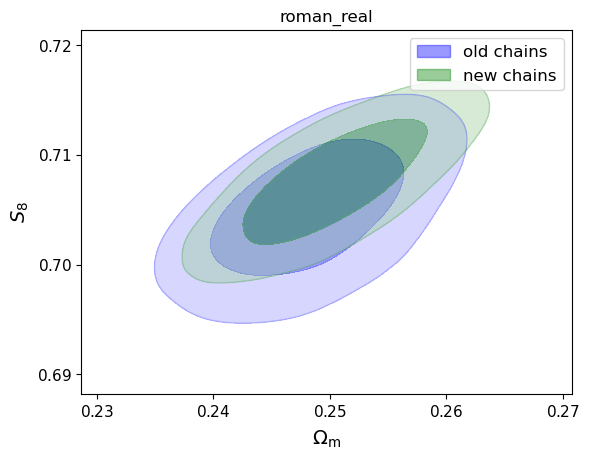

In [6]:
g = plots.get_single_plotter(width_inch=6)
g.settings.tight_layout = True
g.settings.legend_frac_subplot_margin = 0.05
g.plot_2d([samples_old, samples_new],
            param1 = 'omegam',
            param2 = 'S8',
            filled= True,
            colors=['b', 'g'],
            alphas=[0.4, 0.4],
        )
g.add_legend(['old chains','new chains'], legend_loc='upper right')
plt.title('roman_real')